In [1]:
import tensorflow as tf
tf.__version__

'2.20.0'

In [2]:
# Do we have access to a GPU?
device_list = tf.config.list_physical_devices()
if "GPU" in [device.device_type for device in device_list]:
  print(f"[INFO] TensorFlow has GPU available to use. Woohoo!! Computing will be sped up!")
  print(f"[INFO] Accessible devices:\n{device_list}")
else:
  print(f"[INFO] TensorFlow does not have GPU available to use. Models may take a while to train.")
  print(f"[INFO] Accessible devices:\n{device_list}")

[INFO] TensorFlow has GPU available to use. Woohoo!! Computing will be sped up!
[INFO] Accessible devices:
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
import tensorflow as tf

In [4]:
tf.__version__

'2.20.0'

In [5]:
# Check available devices
device_list = tf.config.list_physical_devices()

if "GPU" in [device.device_type for device in device_list]:
    print("TensorFlow has GPU available!")
    print(device_list)
else:
    print("TensorFlow does not have GPU available.")
    print(device_list)

TensorFlow has GPU available!
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
!nvidia-smi

Mon Sep 28 16:09:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             12W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [7]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

gpu_list = tf.config.list_physical_devices("GPU")

if gpu_list:
    print("GPU is available!")
    print(gpu_list)
else:
    print("GPU is NOT available.")

TensorFlow version: 2.20.0
GPU is available!
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [8]:
!wget -nc http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar -P /content/dog_vision_data
!wget -nc http://vision.stanford.edu/aditya86/ImageNetDogs/annotation.tar -P /content/dog_vision_data
!wget -nc http://vision.stanford.edu/aditya86/ImageNetDogs/lists.tar -P /content/dog_vision_data

--2026-09-28 16:09:48--  http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar
Resolving vision.stanford.edu (vision.stanford.edu)... 171.64.68.10
Connecting to vision.stanford.edu (vision.stanford.edu)|171.64.68.10|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 793579520 (757M) [application/x-tar]
Saving to: ‘/content/dog_vision_data/images.tar’

images.tar          100%[===================>] 756.82M  13.3MB/s    in 69s     

2026-09-28 16:10:58 (10.9 MB/s) - ‘/content/dog_vision_data/images.tar’ saved [793579520/793579520]

--2026-09-28 16:10:58--  http://vision.stanford.edu/aditya86/ImageNetDogs/annotation.tar
Resolving vision.stanford.edu (vision.stanford.edu)... 171.64.68.10
Connecting to vision.stanford.edu (vision.stanford.edu)|171.64.68.10|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 21852160 (21M) [application/x-tar]
Saving to: ‘/content/dog_vision_data/annotation.tar’

annotation.tar      100%[===================>]  

In [9]:
from pathlib import Path

data_dir = Path("/content/dog_vision_data")

for file in data_dir.iterdir():
    print(file.name, "->", round(file.stat().st_size / (1024**2), 2), "MB")

images.tar -> 756.82 MB
lists.tar -> 0.46 MB
annotation.tar -> 20.84 MB


In [10]:
from google.colab import drive

drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [11]:
from pathlib import Path

data_dir = Path("/content/dog_vision_data")

for file in data_dir.iterdir():
    print(file.name, "->", round(file.stat().st_size / (1024**2), 2), "MB")

images.tar -> 756.82 MB
lists.tar -> 0.46 MB
annotation.tar -> 20.84 MB


In [12]:
from pathlib import Path

drive_dir = Path("/content/drive/MyDrive/tensorflow/dog_vision_data")

drive_dir.mkdir(parents=True, exist_ok=True)

print("Drive folder created successfully!")
print(drive_dir)

Drive folder created successfully!
/content/drive/MyDrive/tensorflow/dog_vision_data


In [13]:
!cp /content/dog_vision_data/*.tar /content/drive/MyDrive/tensorflow/dog_vision_data/

In [14]:
for file in drive_dir.iterdir():
    print(file.name, "->", round(file.stat().st_size / (1024**2), 2), "MB")

annotation.tar -> 20.84 MB
images.tar -> 756.82 MB
lists.tar -> 0.46 MB


In [15]:
!tar -xf /content/dog_vision_data/images.tar


In [16]:
!tar -xf /content/dog_vision_data/annotation.tar

In [17]:
!tar -xf /content/dog_vision_data/lists.tar

In [18]:
import os

items = os.listdir("/content")

for item in items:
    print(item)

.config
Images
drive
train_list.mat
file_list.mat
test_list.mat
dog_vision_data
Annotation
sample_data


In [19]:
from pathlib import Path

images_dir = Path("/content/Images")

print("Number of breed folders:", len(list(images_dir.iterdir())))

print("\nFirst 10 breed folders:")

for folder in list(images_dir.iterdir())[:10]:
    print(folder.name)

Number of breed folders: 120

First 10 breed folders:
n02107908-Appenzeller
n02090721-Irish_wolfhound
n02105641-Old_English_sheepdog
n02093256-Staffordshire_bullterrier
n02107683-Bernese_mountain_dog
n02097298-Scotch_terrier
n02100236-German_short-haired_pointer
n02111889-Samoyed
n02102040-English_springer
n02099712-Labrador_retriever


In [20]:
import os

image_folders = os.listdir("/content/Images")

print("Number of breed folders:", len(image_folders))
print("\nFirst 10 breed folders:")

for folder in image_folders[:10]:
    print(folder)

Number of breed folders: 120

First 10 breed folders:
n02107908-Appenzeller
n02090721-Irish_wolfhound
n02105641-Old_English_sheepdog
n02093256-Staffordshire_bullterrier
n02107683-Bernese_mountain_dog
n02097298-Scotch_terrier
n02100236-German_short-haired_pointer
n02111889-Samoyed
n02102040-English_springer
n02099712-Labrador_retriever


In [21]:
folder_to_class_name_dict = {}

for folder_name in image_folders:
    class_name = "_".join(folder_name.split("-")[1:]).lower()
    folder_to_class_name_dict[folder_name] = class_name

print("Number of breeds:", len(folder_to_class_name_dict))
print("\nFirst 10 breed mappings:")

for item in list(folder_to_class_name_dict.items())[:10]:
    print(item)

Number of breeds: 120

First 10 breed mappings:
('n02107908-Appenzeller', 'appenzeller')
('n02090721-Irish_wolfhound', 'irish_wolfhound')
('n02105641-Old_English_sheepdog', 'old_english_sheepdog')
('n02093256-Staffordshire_bullterrier', 'staffordshire_bullterrier')
('n02107683-Bernese_mountain_dog', 'bernese_mountain_dog')
('n02097298-Scotch_terrier', 'scotch_terrier')
('n02100236-German_short-haired_pointer', 'german_short_haired_pointer')
('n02111889-Samoyed', 'samoyed')
('n02102040-English_springer', 'english_springer')
('n02099712-Labrador_retriever', 'labrador_retriever')


In [22]:
dog_names = sorted(list(folder_to_class_name_dict.values()))

print("Number of breeds:", len(dog_names))
print("\nFirst 20 breeds:")

for breed in dog_names[:20]:
    print(breed)

Number of breeds: 120

First 20 breeds:
affenpinscher
afghan_hound
african_hunting_dog
airedale
american_staffordshire_terrier
appenzeller
australian_terrier
basenji
basset
beagle
bedlington_terrier
bernese_mountain_dog
black_and_tan_coonhound
blenheim_spaniel
bloodhound
bluetick
border_collie
border_terrier
borzoi
boston_bull


In [ ]:
import scipy.io

train_list = scipy.io.loadmat("/content/train_list.mat")
test_list = scipy.io.loadmat("/content/test_list.mat")
file_list = scipy.io.loadmat("/content/file_list.mat")

print("MAT files loaded successfully!")
print("Training entries:", len(train_list["file_list"]))
print("Testing entries:", len(test_list["file_list"]))
print("Total entries:", len(file_list["file_list"]))

MAT files loaded successfully!
Training entries: 12000
Testing entries: 8580
Total entries: 20580


In [ ]:
train_file_list = [item[0][0] for item in train_list["file_list"]]
test_file_list = [item[0][0] for item in test_list["file_list"]]
full_file_list = [item[0][0] for item in file_list["file_list"]]

print("Training images:", len(train_file_list))
print("Testing images:", len(test_file_list))
print("Total images:", len(full_file_list))

Training images: 12000
Testing images: 8580
Total images: 20580


In [24]:
import scipy.io

train_list = scipy.io.loadmat("/content/train_list.mat")

train_file_list = [
    item[0][0] for item in train_list["file_list"]
]

print("Training images loaded:", len(train_file_list))
print("First image:", train_file_list[0])

Training images loaded: 12000
First image: n02085620-Chihuahua/n02085620_5927.jpg


Image path:
/content/Images/n02085620-Chihuahua/n02085620_5927.jpg


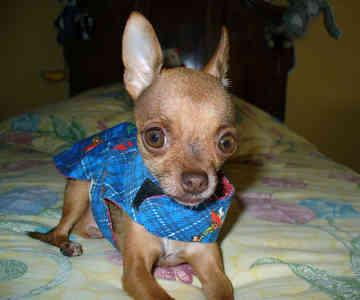

In [25]:
from IPython.display import Image, display
from pathlib import Path

sample_image = Path("/content/Images") / train_file_list[0]

print("Image path:")
print(sample_image)

display(Image(filename=str(sample_image)))

Image path:
/content/Images/n02085620-Chihuahua/n02085620_5927.jpg


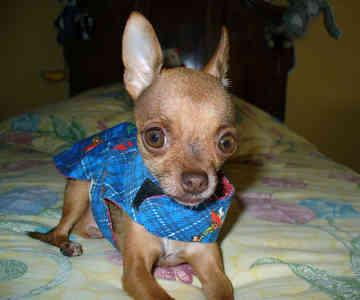

In [26]:
from IPython.display import Image, display
from pathlib import Path

sample_image = Path("/content/Images") / train_file_list[0]

print("Image path:")
print(sample_image)

display(Image(filename=str(sample_image)))

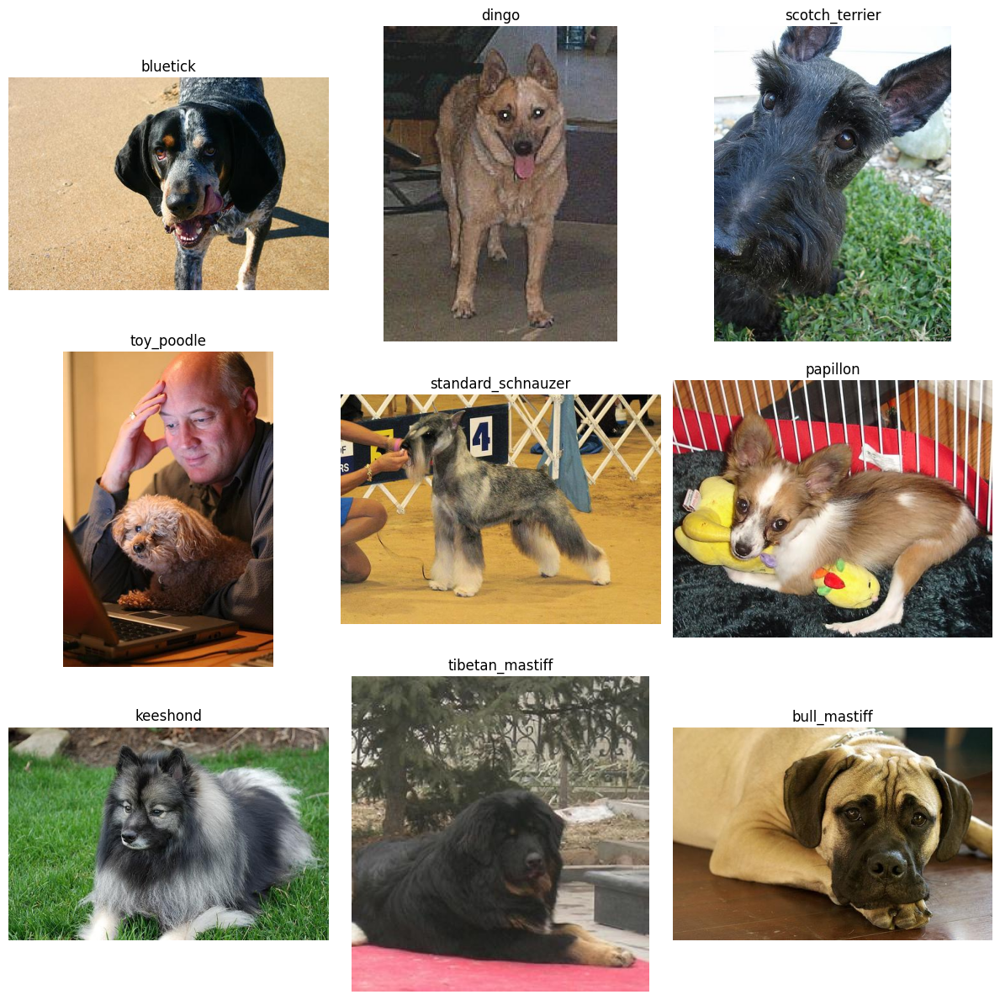

In [27]:
import random
import matplotlib.pyplot as plt
from PIL import Image as PILImage

# Select 9 random training images
random_images = random.sample(train_file_list, 9)

# Create a 3 x 3 grid
plt.figure(figsize=(12, 12))

for i, image_path in enumerate(random_images):

    # Open image
    image = PILImage.open("/content/Images/" + image_path)

    # Display image
    plt.subplot(3, 3, i + 1)
    plt.imshow(image)

    # Get breed/folder name
    breed = image_path.split("/")[0]
    breed_name = folder_to_class_name_dict[breed]

    plt.title(breed_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [28]:
from pathlib import Path

image_counts = {}

for folder in image_folders:
    folder_path = Path("/content/Images") / folder

    # Count JPG images
    count = len(list(folder_path.glob("*.jpg")))

    image_counts[folder] = count

print("Total images:", sum(image_counts.values()))
print("Number of breeds:", len(image_counts))

Total images: 20580
Number of breeds: 120


In [29]:
sorted_counts = sorted(image_counts.items(), key=lambda x: x[1])

print("10 breeds with the fewest images:\n")

for breed, count in sorted_counts[:10]:
    print(folder_to_class_name_dict[breed], ":", count)

print("\n10 breeds with the most images:\n")

for breed, count in sorted_counts[-10:]:
    print(folder_to_class_name_dict[breed], ":", count)

10 breeds with the fewest images:

redbone : 148
pekinese : 149
border_collie : 150
kuvasz : 150
malinois : 150
affenpinscher : 150
doberman : 150
golden_retriever : 150
clumber : 150
welsh_springer_spaniel : 150

10 breeds with the most images:

leonberg : 210
great_pyrenees : 213
shih_tzu : 214
irish_wolfhound : 218
bernese_mountain_dog : 218
samoyed : 218
pomeranian : 219
scottish_deerhound : 232
afghan_hound : 239
maltese_dog : 252


In [30]:
from google.colab import drive

drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [31]:
!ls -lh /content/drive/MyDrive/tensorflow/dog_vision_data/

total 779M
-rw------- 1 root root  21M Sep 28 16:11 annotation.tar
-rw------- 1 root root 757M Sep 28 16:12 images.tar
-rw------- 1 root root 470K Sep 28 16:12 lists.tar


In [32]:
!mkdir -p /content/dog_vision_data

!cp /content/drive/MyDrive/tensorflow/dog_vision_data/*.tar /content/dog_vision_data/

!ls -lh /content/dog_vision_data/

total 779M
-rw-r--r-- 1 root root  21M Sep 28 16:16 annotation.tar
-rw-r--r-- 1 root root 757M Sep 28 16:16 images.tar
-rw-r--r-- 1 root root 470K Sep 28 16:16 lists.tar


In [33]:
!tar -xf /content/dog_vision_data/images.tar -C /content/

In [34]:
!tar -xf /content/dog_vision_data/annotation.tar -C /content/

In [35]:
!tar -xf /content/dog_vision_data/lists.tar -C /content/

In [36]:
import os

print("Images folder exists:", os.path.exists("/content/Images"))
print("Annotation folder exists:", os.path.exists("/content/Annotation"))
print("train_list.mat exists:", os.path.exists("/content/train_list.mat"))
print("test_list.mat exists:", os.path.exists("/content/test_list.mat"))
print("file_list.mat exists:", os.path.exists("/content/file_list.mat"))

Images folder exists: True
Annotation folder exists: True
train_list.mat exists: True
test_list.mat exists: True
file_list.mat exists: True


In [37]:
import os
import scipy.io
from pathlib import Path

# ==========================================
# 1. Load MATLAB file lists
# ==========================================

train_list = scipy.io.loadmat("/content/train_list.mat")
test_list = scipy.io.loadmat("/content/test_list.mat")
file_list = scipy.io.loadmat("/content/file_list.mat")


# ==========================================
# 2. Convert file lists to Python lists
# ==========================================

train_file_list = [item[0][0] for item in train_list["file_list"]]
test_file_list = [item[0][0] for item in test_list["file_list"]]
full_file_list = [item[0][0] for item in file_list["file_list"]]


# ==========================================
# 3. Get breed folders
# ==========================================

image_folders = os.listdir("/content/Images")


# ==========================================
# 4. Create breed-name mapping
# ==========================================

folder_to_class_name_dict = {}

for folder_name in image_folders:
    class_name = "_".join(folder_name.split("-")[1:]).lower()
    folder_to_class_name_dict[folder_name] = class_name


# ==========================================
# 5. Create sorted breed names
# ==========================================

dog_names = sorted(list(folder_to_class_name_dict.values()))


# ==========================================
# 6. Count images in every breed
# ==========================================

image_counts = {}

for folder in image_folders:
    folder_path = Path("/content/Images") / folder
    image_counts[folder] = len(list(folder_path.glob("*.jpg")))


# ==========================================
# 7. Print everything to verify
# ==========================================

print("========== DATASET CHECK ==========")
print("Training images:", len(train_file_list))
print("Testing images:", len(test_file_list))
print("Total images:", len(full_file_list))
print("Number of breeds:", len(image_folders))
print("Total images counted in folders:", sum(image_counts.values()))

print("\n========== VARIABLES CREATED ==========")
print("train_file_list             ✓")
print("test_file_list              ✓")
print("full_file_list              ✓")
print("image_folders               ✓")
print("folder_to_class_name_dict   ✓")
print("dog_names                   ✓")
print("image_counts                ✓")

print("\n========== FIRST 10 BREEDS ==========")
for breed in dog_names[:10]:
    print(breed)

========== DATASET CHECK ==========
Training images: 12000
Testing images: 8580
Total images: 20580
Number of breeds: 120
Total images counted in folders: 20580

========== VARIABLES CREATED ==========
train_file_list             ✓
test_file_list              ✓
full_file_list              ✓
image_folders               ✓
folder_to_class_name_dict   ✓
dog_names                   ✓
image_counts                ✓

========== FIRST 10 BREEDS ==========
affenpinscher
afghan_hound
african_hunting_dog
airedale
american_staffordshire_terrier
appenzeller
australian_terrier
basenji
basset
beagle


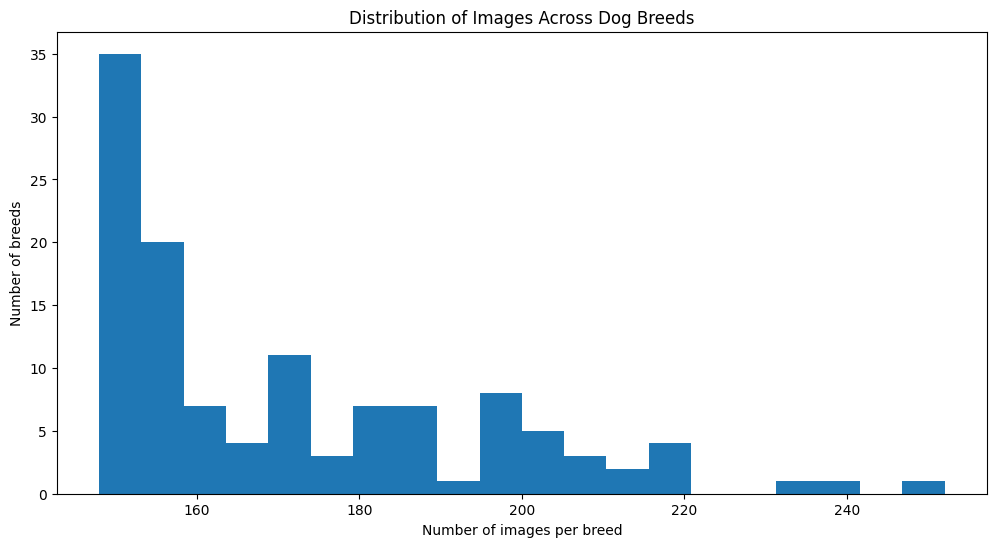

In [38]:
import matplotlib.pyplot as plt

counts = list(image_counts.values())

plt.figure(figsize=(12, 6))

plt.hist(counts, bins=20)

plt.xlabel("Number of images per breed")
plt.ylabel("Number of breeds")
plt.title("Distribution of Images Across Dog Breeds")

plt.show()

In [39]:
from pathlib import Path

base_dir = Path("/content/dog_data")

train_dir = base_dir / "train"
test_dir = base_dir / "test"

train_dir.mkdir(parents=True, exist_ok=True)
test_dir.mkdir(parents=True, exist_ok=True)

# Create one folder for every breed
for breed_folder in image_folders:
    (train_dir / breed_folder).mkdir(parents=True, exist_ok=True)
    (test_dir / breed_folder).mkdir(parents=True, exist_ok=True)

print("Training directory:", train_dir)
print("Testing directory:", test_dir)
print("Number of breed folders:", len(image_folders))

Training directory: /content/dog_data/train
Testing directory: /content/dog_data/test
Number of breed folders: 120


In [40]:
import random

random.seed(42)

train_10_percent = random.sample(
    train_file_list,
    k=int(len(train_file_list) * 0.10)
)

print("Original training images:", len(train_file_list))
print("10% training images:", len(train_10_percent))

Original training images: 12000
10% training images: 1200


In [41]:
import shutil

for image_path in train_10_percent:
    source = Path("/content/Images") / image_path

    breed_folder = image_path.split("/")[0]

    destination = train_dir / breed_folder / Path(image_path).name

    shutil.copy2(source, destination)

print("1,200 training images copied successfully!")

1,200 training images copied successfully!


In [42]:
for image_path in test_file_list:
    source = Path("/content/Images") / image_path

    breed_folder = image_path.split("/")[0]

    destination = test_dir / breed_folder / Path(image_path).name

    shutil.copy2(source, destination)

print("8,580 test images copied successfully!")

8,580 test images copied successfully!


In [43]:
train_count = len(list(train_dir.glob("*/*.jpg")))
test_count = len(list(test_dir.glob("*/*.jpg")))

print("========== NEW DATASET ==========")
print("Training images:", train_count)
print("Testing images:", test_count)
print("Total images:", train_count + test_count)

========== NEW DATASET ==========
Training images: 1200
Testing images: 8580
Total images: 9780


In [44]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [45]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

print("\nTraining dataset created successfully!")

Found 1200 files belonging to 120 classes.

Training dataset created successfully!


In [46]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

print("\nTraining dataset created successfully!")

Found 1200 files belonging to 120 classes.

Training dataset created successfully!


In [47]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("\nTest dataset created successfully!")

Found 8580 files belonging to 120 classes.

Test dataset created successfully!


In [48]:
class_names = train_ds.class_names

print("Number of classes:", len(class_names))

print("\nFirst 20 dog breeds:")
for i, name in enumerate(class_names[:20]):
    print(i, "→", name)

Number of classes: 120

First 20 dog breeds:
0 → n02085620-Chihuahua
1 → n02085782-Japanese_spaniel
2 → n02085936-Maltese_dog
3 → n02086079-Pekinese
4 → n02086240-Shih-Tzu
5 → n02086646-Blenheim_spaniel
6 → n02086910-papillon
7 → n02087046-toy_terrier
8 → n02087394-Rhodesian_ridgeback
9 → n02088094-Afghan_hound
10 → n02088238-basset
11 → n02088364-beagle
12 → n02088466-bloodhound
13 → n02088632-bluetick
14 → n02089078-black-and-tan_coonhound
15 → n02089867-Walker_hound
16 → n02089973-English_foxhound
17 → n02090379-redbone
18 → n02090622-borzoi
19 → n02090721-Irish_wolfhound


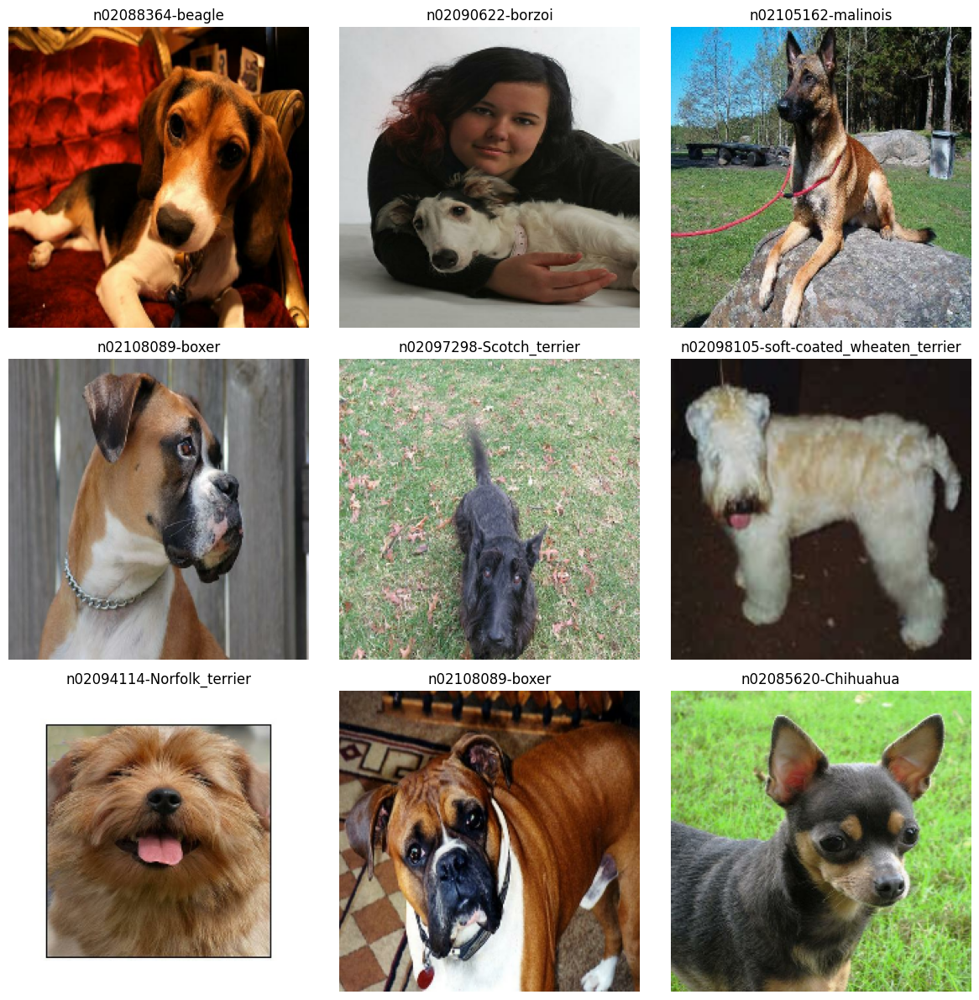

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 12))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [50]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

print("Dataset performance optimization completed!")

Dataset performance optimization completed!


In [53]:
import tensorflow as tf

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

print("Dataset performance optimization completed!")

Dataset performance optimization completed!


In [54]:
import tensorflow as tf
from tensorflow.keras import layers

base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

print("EfficientNetB0 loaded successfully!")
print("Base model trainable:", base_model.trainable)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
EfficientNetB0 loaded successfully!
Base model trainable: False


In [55]:
inputs = layers.Input(shape=(224, 224, 3))

x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)

outputs = layers.Dense(
    120,
    activation="softmax"
)(x)

model = tf.keras.Model(inputs, outputs)

print("Model created successfully!")

Model created successfully!


In [56]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │       153,720 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,203,291 (16.03 MB)

 Trainable params: 153,720 (600.47 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [57]:
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [58]:
history_0 = model.fit(
    train_ds,
    epochs=5,
    validation_data=test_ds
)

Epoch 1/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.1958 - loss: 4.1135 - val_accuracy: 0.4587 - val_loss: 3.1779
Epoch 2/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 18s 488ms/step - accuracy: 0.6808 - loss: 2.2707 - val_accuracy: 0.5888 - val_loss: 2.1222
Epoch 3/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 17s 387ms/step - accuracy: 0.8242 - loss: 1.3343 - val_accuracy: 0.6633 - val_loss: 1.5762
Epoch 4/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 21s 403ms/step - accuracy: 0.8958 - loss: 0.8742 - val_accuracy: 0.7072 - val_loss: 1.2924
Epoch 5/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 15s 391ms/step - accuracy: 0.9342 - loss: 0.6346 - val_accuracy: 0.7303 - val_loss: 1.1340


In [59]:
print("Final training accuracy:",
      history_0.history["accuracy"][-1])

print("Final validation accuracy:",
      history_0.history["val_accuracy"][-1])

Final training accuracy: 0.934166669845581
Final validation accuracy: 0.7303030490875244


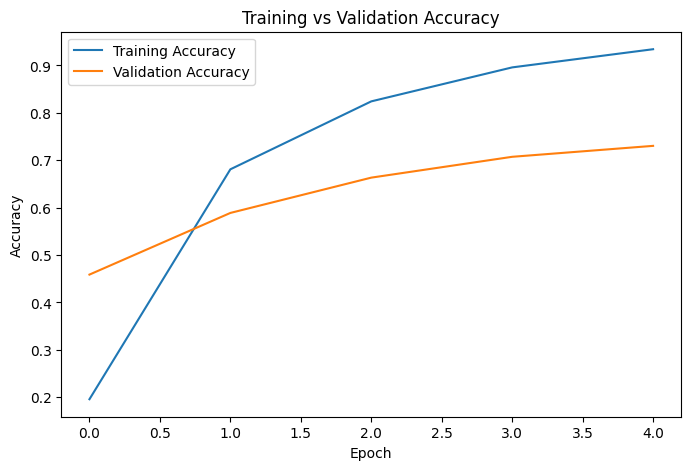

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history_0.history["accuracy"], label="Training Accuracy")
plt.plot(history_0.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

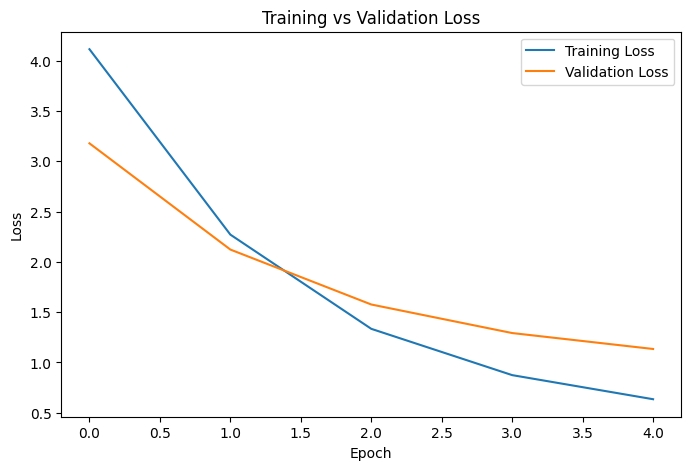

In [61]:
plt.figure(figsize=(8, 5))

plt.plot(history_0.history["loss"], label="Training Loss")
plt.plot(history_0.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [62]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("\n========== MODEL 0 RESULTS ==========")
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

269/269 ━━━━━━━━━━━━━━━━━━━━ 16s 61ms/step - accuracy: 0.7303 - loss: 1.1340

========== MODEL 0 RESULTS ==========
Test Loss: 1.1340299844741821
Test Accuracy: 0.7303030490875244


In [63]:
from pathlib import Path

full_train_dir = Path("/content/dog_data/full_train")

full_train_dir.mkdir(parents=True, exist_ok=True)

for breed_folder in image_folders:
    (full_train_dir / breed_folder).mkdir(
        parents=True,
        exist_ok=True
    )

print("Full training folders created!")
print("Number of breed folders:", len(image_folders))

Full training folders created!
Number of breed folders: 120


In [64]:
import shutil

for image_path in train_file_list:
    source = Path("/content/Images") / image_path

    breed_folder = image_path.split("/")[0]

    destination = (
        full_train_dir / breed_folder / Path(image_path).name
    )

    shutil.copy2(source, destination)

print("All 12,000 training images copied successfully!")

All 12,000 training images copied successfully!


In [66]:
full_train_ds = tf.keras.utils.image_dataset_from_directory(
    full_train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

print("Full training dataset created!")

Found 12000 files belonging to 120 classes.
Full training dataset created!


In [67]:
full_train_ds = full_train_ds.prefetch(
    buffer_size=tf.data.AUTOTUNE
)

print("Full training dataset optimized!")

Full training dataset optimized!


In [68]:
from tensorflow.keras import layers
import tensorflow as tf

base_model_1 = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model_1.trainable = False

inputs_1 = layers.Input(shape=(224, 224, 3))

x = base_model_1(inputs_1, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)

outputs_1 = layers.Dense(
    120,
    activation="softmax"
)(x)

model_1 = tf.keras.Model(inputs_1, outputs_1)

model_1.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

print("Model 1 created and compiled successfully!")

Model 1 created and compiled successfully!


In [69]:
history_1 = model_1.fit(
    full_train_ds,
    epochs=5,
    validation_data=test_ds
)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 82s 151ms/step - accuracy: 0.6798 - loss: 1.5536 - val_accuracy: 0.8345 - val_loss: 0.6488
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 36s 95ms/step - accuracy: 0.8557 - loss: 0.5458 - val_accuracy: 0.8528 - val_loss: 0.5157
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 43s 114ms/step - accuracy: 0.8914 - loss: 0.4045 - val_accuracy: 0.8578 - val_loss: 0.4750
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 42s 113ms/step - accuracy: 0.9124 - loss: 0.3305 - val_accuracy: 0.8590 - val_loss: 0.4632
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 111ms/step - accuracy: 0.9267 - loss: 0.2754 - val_accuracy: 0.8593 - val_loss: 0.4523


In [70]:
print("Final training accuracy:",
      history_1.history["accuracy"][-1])

print("Final validation accuracy:",
      history_1.history["val_accuracy"][-1])

Final training accuracy: 0.9266666769981384
Final validation accuracy: 0.859324038028717


In [71]:
test_loss_1, test_accuracy_1 = model_1.evaluate(test_ds)

print("\n========== MODEL 1 RESULTS ==========")
print("Test Loss:", test_loss_1)
print("Test Accuracy:", test_accuracy_1)
print("Test Accuracy (%):", round(test_accuracy_1 * 100, 2))

269/269 ━━━━━━━━━━━━━━━━━━━━ 18s 65ms/step - accuracy: 0.8593 - loss: 0.4523

========== MODEL 1 RESULTS ==========
Test Loss: 0.45234352350234985
Test Accuracy: 0.859324038028717
Test Accuracy (%): 85.93


In [72]:
import numpy as np

predictions = model_1.predict(test_ds)

predicted_classes = np.argmax(predictions, axis=1)

print("Predictions generated successfully!")
print("Number of predictions:", len(predicted_classes))

269/269 ━━━━━━━━━━━━━━━━━━━━ 34s 95ms/step
Predictions generated successfully!
Number of predictions: 8580


In [73]:
actual_classes = np.concatenate([
    labels.numpy()
    for images, labels in test_ds
])

print("Actual labels:", len(actual_classes))

Actual labels: 8580


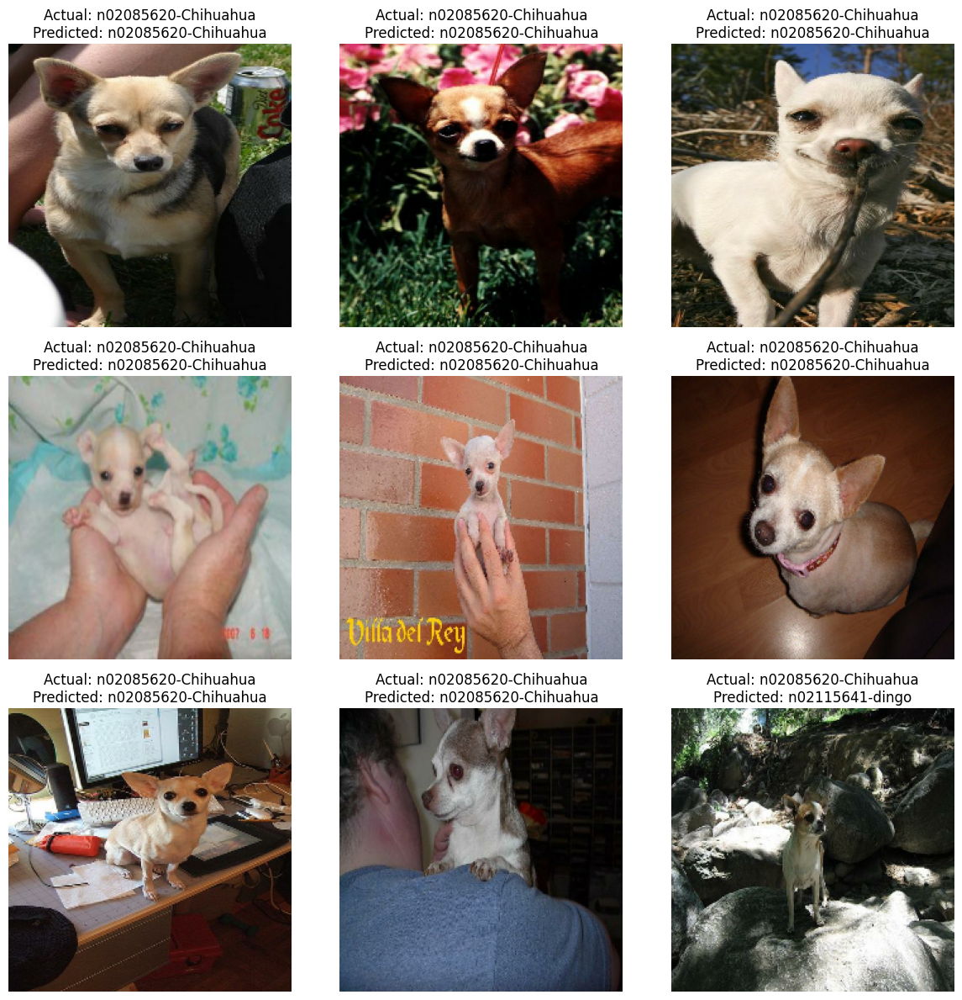

In [74]:
import matplotlib.pyplot as plt
import numpy as np

for images, labels in test_ds.take(1):
    plt.figure(figsize=(12, 12))

    for i in range(9):
        plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        actual = class_names[labels[i]]
        predicted = class_names[predicted_classes[i]]

        plt.title(
            f"Actual: {actual}\nPredicted: {predicted}"
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [75]:
wrong_indices = np.where(predicted_classes != actual_classes)[0]

print("Total test images:", len(actual_classes))
print("Wrong predictions:", len(wrong_indices))
print("Correct predictions:", len(actual_classes) - len(wrong_indices))

Total test images: 8580
Wrong predictions: 1207
Correct predictions: 7373


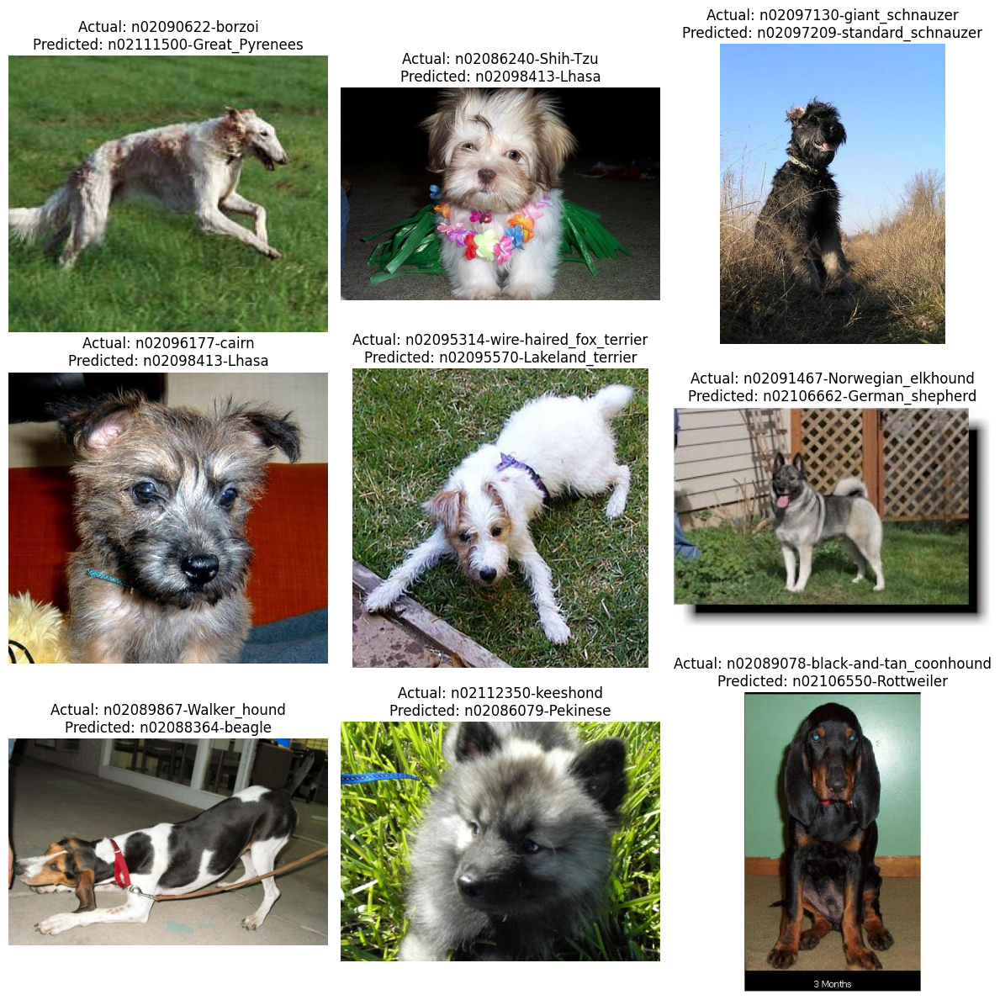

In [76]:
import random
import matplotlib.pyplot as plt
from PIL import Image as PILImage

random.seed(42)

sample_wrong = random.sample(
    list(wrong_indices),
    min(9, len(wrong_indices))
)

plt.figure(figsize=(12, 12))

for i, index in enumerate(sample_wrong):

    image_path = Path("/content/Images") / test_file_list[index]

    image = PILImage.open(image_path)

    actual = class_names[actual_classes[index]]
    predicted = class_names[predicted_classes[index]]

    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [77]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    actual_classes,
    predicted_classes
)

print("Confusion matrix shape:", cm.shape)

Confusion matrix shape: (120, 120)


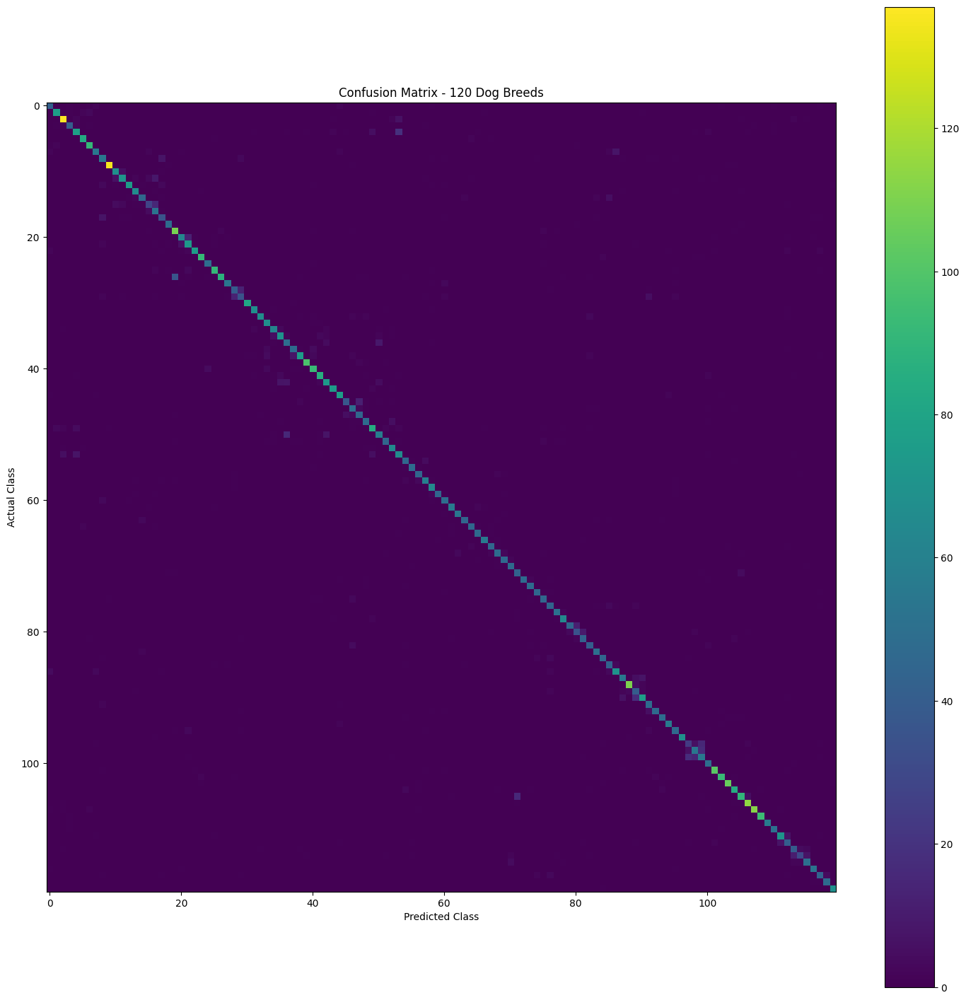

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 18))

plt.imshow(cm)

plt.title("Confusion Matrix - 120 Dog Breeds")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.colorbar()

plt.show()

In [79]:
per_class_accuracy = []

for i in range(len(class_names)):
    total = np.sum(actual_classes == i)

    correct = np.sum(
        (actual_classes == i) &
        (predicted_classes == i)
    )

    accuracy = correct / total if total > 0 else 0

    per_class_accuracy.append(accuracy)

print("Per-class accuracy calculated!")
print("Number of breeds:", len(per_class_accuracy))

Per-class accuracy calculated!
Number of breeds: 120


In [80]:
for breed, accuracy in zip(class_names, per_class_accuracy):
    print(f"{breed:35s} : {accuracy * 100:.2f}%")

n02085620-Chihuahua                 : 80.77%
n02085782-Japanese_spaniel          : 89.41%
n02085936-Maltese_dog               : 90.13%
n02086079-Pekinese                  : 83.67%
n02086240-Shih-Tzu                  : 68.42%
n02086646-Blenheim_spaniel          : 95.45%
n02086910-papillon                  : 94.79%
n02087046-toy_terrier               : 76.39%
n02087394-Rhodesian_ridgeback       : 76.39%
n02088094-Afghan_hound              : 97.12%
n02088238-basset                    : 92.00%
n02088364-beagle                    : 74.74%
n02088466-bloodhound                : 86.21%
n02088632-bluetick                  : 92.96%
n02089078-black-and-tan_coonhound   : 77.97%
n02089867-Walker_hound              : 52.83%
n02089973-English_foxhound          : 91.23%
n02090379-redbone                   : 72.92%
n02090622-borzoi                    : 94.12%
n02090721-Irish_wolfhound           : 92.37%
n02091032-Italian_greyhound         : 76.83%
n02091134-whippet                   : 85.06%
n02091244-

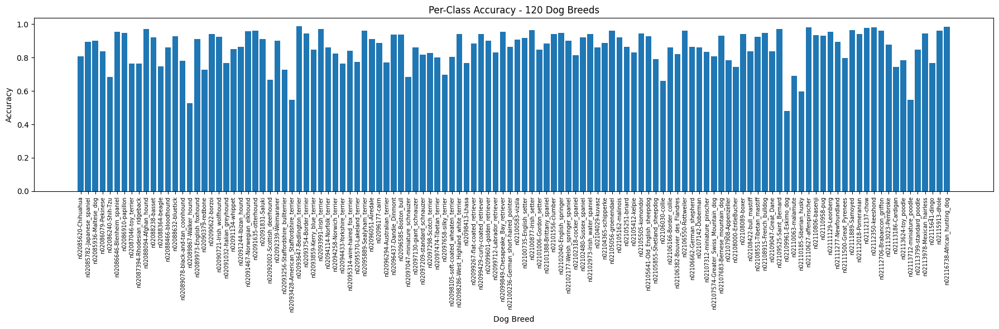

In [81]:
plt.figure(figsize=(18, 6))

plt.bar(range(len(class_names)), per_class_accuracy)

plt.xlabel("Dog Breed")
plt.ylabel("Accuracy")
plt.title("Per-Class Accuracy - 120 Dog Breeds")

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=90,
    fontsize=7
)

plt.tight_layout()
plt.show()

In [82]:
model_1.save("/content/dog_breed_model.keras")

print("Model saved successfully!")

Model saved successfully!


In [83]:
from pathlib import Path

model_path = Path("/content/dog_breed_model.keras")

print("Model exists:", model_path.exists())
print("Model size:", round(model_path.stat().st_size / (1024 * 1024), 2), "MB")

Model exists: True
Model size: 18.01 MB


In [84]:
from google.colab import drive
from pathlib import Path
import shutil

drive.mount("/content/drive", force_remount=True)

drive_model_path = Path(
    "/content/drive/MyDrive/tensorflow/dog_breed_model.keras"
)

drive_model_path.parent.mkdir(parents=True, exist_ok=True)

shutil.copy2(
    "/content/dog_breed_model.keras",
    drive_model_path
)

print("Model backed up to Google Drive!")
print(drive_model_path)

Mounted at /content/drive
Model backed up to Google Drive!
/content/drive/MyDrive/tensorflow/dog_breed_model.keras


In [85]:
loaded_model = tf.keras.models.load_model(
    "/content/dog_breed_model.keras"
)

print("Model loaded successfully!")
print("Output shape:", loaded_model.output_shape)

Model loaded successfully!
Output shape: (None, 120)


In [87]:
from google.colab import files

uploaded = files.upload()

Saving image.jpg to image.jpg


Image: image.jpg
Original size: (678, 452)


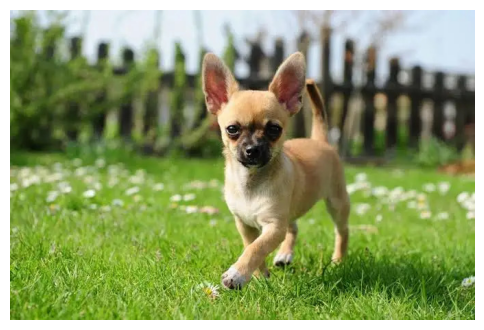

In [88]:
from PIL import Image
import matplotlib.pyplot as plt

image_name = list(uploaded.keys())[0]

image = Image.open(image_name).convert("RGB")

print("Image:", image_name)
print("Original size:", image.size)

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.show()

In [89]:
import numpy as np

image_resized = image.resize((224, 224))

image_array = np.array(image_resized)

image_batch = np.expand_dims(image_array, axis=0)

print("Image batch shape:", image_batch.shape)

Image batch shape: (1, 224, 224, 3)


In [90]:
prediction = loaded_model.predict(image_batch)

predicted_index = np.argmax(prediction[0])

predicted_breed = class_names[predicted_index]

confidence = prediction[0][predicted_index] * 100

print("========== PREDICTION ==========")
print("Predicted breed:", predicted_breed)
print("Confidence:", round(confidence, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 18s 18s/step
========== PREDICTION ==========
Predicted breed: n02085620-Chihuahua
Confidence: 97.72 %


In [91]:
top_5_indices = np.argsort(prediction[0])[-5:][::-1]

print("========== TOP 5 PREDICTIONS ==========")

for rank, index in enumerate(top_5_indices, start=1):
    breed = class_names[index]
    confidence = prediction[0][index] * 100

    print(
        f"{rank}. {breed:35s} "
        f"{confidence:.2f}%"
    )

========== TOP 5 PREDICTIONS ==========
1. n02085620-Chihuahua                 97.72%
2. n02087046-toy_terrier               2.02%
3. n02110806-basenji                   0.07%
4. n02107312-miniature_pinscher        0.06%
5. n02113978-Mexican_hairless          0.03%


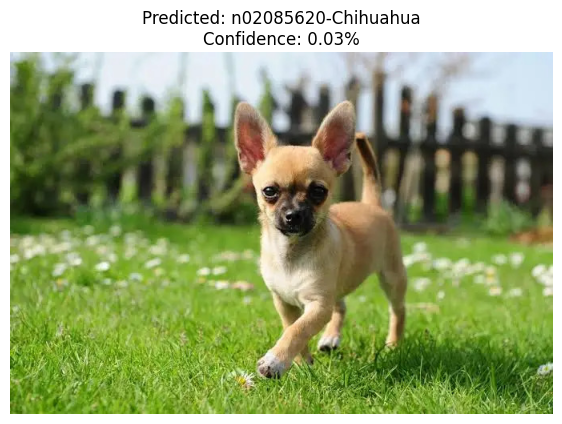

In [92]:
plt.figure(figsize=(7, 7))

plt.imshow(image)

plt.title(
    f"Predicted: {predicted_breed}\n"
    f"Confidence: {confidence:.2f}%"
)

plt.axis("off")
plt.show()

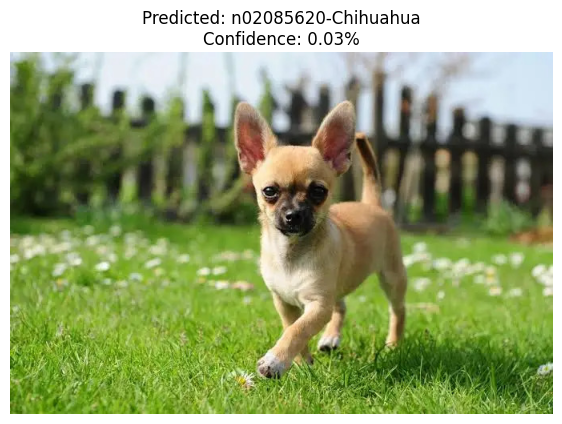

In [93]:
plt.figure(figsize=(7, 7))

plt.imshow(image)

plt.title(
    f"Predicted: {predicted_breed}\n"
    f"Confidence: {confidence:.2f}%"
)

plt.axis("off")
plt.show()

In [94]:
if confidence >= 80:
    message = "High confidence"
elif confidence >= 50:
    message = "Moderate confidence"
else:
    message = "Low confidence"

print("Predicted breed:", predicted_breed)
print("Confidence:", round(confidence, 2), "%")
print("Interpretation:", message)

Predicted breed: n02085620-Chihuahua
Confidence: 0.03 %
Interpretation: Low confidence


In [95]:
base_model_1.trainable = True

for layer in base_model_1.layers[:-20]:
    layer.trainable = False

print("Fine-tuning enabled!")
print("Trainable layers:",
      sum(layer.trainable for layer in base_model_1.layers))

Fine-tuning enabled!
Trainable layers: 20


In [96]:
model_1.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.00001
    ),
    metrics=["accuracy"]
)

print("Model recompiled for fine-tuning!")

Model recompiled for fine-tuning!


In [97]:
history_fine = model_1.fit(
    full_train_ds,
    epochs=3,
    validation_data=test_ds
)

Epoch 1/3
375/375 ━━━━━━━━━━━━━━━━━━━━ 83s 134ms/step - accuracy: 0.8410 - loss: 0.7189 - val_accuracy: 0.8172 - val_loss: 0.6631
Epoch 2/3
375/375 ━━━━━━━━━━━━━━━━━━━━ 38s 100ms/step - accuracy: 0.8742 - loss: 0.5530 - val_accuracy: 0.8317 - val_loss: 0.6046
Epoch 3/3
375/375 ━━━━━━━━━━━━━━━━━━━━ 43s 114ms/step - accuracy: 0.8846 - loss: 0.4754 - val_accuracy: 0.8388 - val_loss: 0.5606
